# Identity Match Test

Batch-tests the ArcFace lookup against LFW-style data and **shows the actual matched photos side by side** with each test photo, so you can eyeball wrong matches instead of just reading distances.

- `KNOWN_FACES_DIR` - the "database": one subfolder per person, reference photo(s) inside.
- `TEST_FACES_DIR` - held-out queries, same one-subfolder-per-person layout.

Run the cells top to bottom. The last cell renders every test photo next to whatever it matched to.

In [1]:
import os
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
from deepface import DeepFace

# Must match FACE_DATABASE_DIR in prototype_facial_recognition.py / enroll_test_subject.py
KNOWN_FACES_DIR = r"C:\FaceRecognition\known_faces"
TEST_FACES_DIR = r"C:\FaceRecognition\test_faces"

ARCFACE_MODEL_NAME = "ArcFace"
ARCFACE_DETECTOR_BACKEND = "retinaface"

IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp"}

## Helper functions

Same logic as the standalone `test_identity_match.py` script - identity comes from the parent folder name (LFW-style), lookup runs through `DeepFace.find()`.

In [2]:
def person_name_from_path(photo_path, root_dir):
    """LFW-style layout: root_dir/Person_Name/some_photo.jpg -> 'Person_Name'."""
    try:
        rel = os.path.relpath(photo_path, root_dir)
        first_part = rel.split(os.sep)[0]
        if first_part != os.pardir and not os.path.isabs(first_part):
            return first_part
    except ValueError:
        pass
    return os.path.basename(os.path.dirname(photo_path))  # fallback: photo not actually under root_dir


def find_match(photo_path, db_path=KNOWN_FACES_DIR):
    """Runs one lookup. Returns (matched_photo_path, distance) or (None, distance-of-closest-miss)."""
    try:
        results = DeepFace.find(
            img_path=photo_path,
            db_path=db_path,
            model_name=ARCFACE_MODEL_NAME,
            detector_backend=ARCFACE_DETECTOR_BACKEND,
            enforce_detection=False,
            silent=True,
        )
    except Exception as e:
        print(f"    Lookup failed on {photo_path}: {e}")
        return None, None

    if not results or len(results[0]) == 0:
        return None, None  # nothing in the database looked close at all

    best = results[0].iloc[0]
    if best["distance"] > best["threshold"]:
        return None, best["distance"]  # closest candidate still isn't within the match threshold

    return best["identity"], best["distance"]


def list_images(root_dir):
    paths = []
    for dirpath, _, filenames in os.walk(root_dir):
        for fn in filenames:
            if Path(fn).suffix.lower() in IMAGE_EXTS:
                paths.append(os.path.join(dirpath, fn))
    return sorted(paths)

## Run the batch lookup

Runs every photo under `TEST_FACES_DIR` against `KNOWN_FACES_DIR` and stores the result for each - this cell can take a while the first time (ArcFace has to load its weights, and `DeepFace.find()` builds an embeddings cache for `KNOWN_FACES_DIR` on its first run).

In [3]:
test_images = list_images(TEST_FACES_DIR)
num_people = len(set(person_name_from_path(p, TEST_FACES_DIR) for p in test_images))
print(f"Found {len(test_images)} test photo(s) across {num_people} people.")
print(f"Running lookups against {KNOWN_FACES_DIR} ...\n")

results = []  # each: dict(photo_path, expected, matched_path, predicted, distance, verdict)

for photo_path in test_images:
    expected = person_name_from_path(photo_path, TEST_FACES_DIR)
    matched_path, distance = find_match(photo_path)

    if matched_path is None:
        predicted = None
        verdict = "NO MATCH"
    else:
        predicted = person_name_from_path(matched_path, KNOWN_FACES_DIR)
        verdict = "CORRECT" if predicted == expected else "WRONG"

    results.append({
        "photo_path": photo_path,
        "expected": expected,
        "matched_path": matched_path,
        "predicted": predicted,
        "distance": distance,
        "verdict": verdict,
    })

    rel = os.path.relpath(photo_path, TEST_FACES_DIR)
    dist_str = f"{distance:.4f}" if distance is not None else "n/a"
    print(f"[{expected:20s}] {rel:45s} {verdict:8s} dist={dist_str}")

Found 30 test photo(s) across 10 people.
Running lookups against C:\FaceRecognition\known_faces ...

[Angelina_Jolie      ] Angelina_Jolie\test_0.jpg                     CORRECT  dist=0.6274
[Angelina_Jolie      ] Angelina_Jolie\test_1.jpg                     CORRECT  dist=0.3955
[Angelina_Jolie      ] Angelina_Jolie\test_2.jpg                     CORRECT  dist=0.3449
[Ariel_Sharon        ] Ariel_Sharon\test_0.jpg                       CORRECT  dist=0.2236
[Ariel_Sharon        ] Ariel_Sharon\test_1.jpg                       CORRECT  dist=0.3094
[Ariel_Sharon        ] Ariel_Sharon\test_2.jpg                       CORRECT  dist=0.4538
[Donald_Rumsfeld     ] Donald_Rumsfeld\test_0.jpg                    CORRECT  dist=0.4276
[Donald_Rumsfeld     ] Donald_Rumsfeld\test_1.jpg                    CORRECT  dist=0.3357
[Donald_Rumsfeld     ] Donald_Rumsfeld\test_2.jpg                    CORRECT  dist=0.4593
[Jacques_Chirac      ] Jacques_Chirac\test_0.jpg                     CORRECT  dist=0.2663

## Summary

In [4]:
total = len(results)
correct = sum(1 for r in results if r["verdict"] == "CORRECT")
wrong = sum(1 for r in results if r["verdict"] == "WRONG")
no_match = sum(1 for r in results if r["verdict"] == "NO MATCH")

print(f"Total test photos : {total}")
print(f"Correct           : {correct} ({100 * correct / total:.1f}%)")
print(f"Wrong person      : {wrong} ({100 * wrong / total:.1f}%)")
print(f"No match at all   : {no_match} ({100 * no_match / total:.1f}%)")

Total test photos : 30
Correct           : 30 (100.0%)
Wrong person      : 0 (0.0%)
No match at all   : 0 (0.0%)


## Show the matched photos

Every test photo next to whatever it matched to in `known_faces` - green title = correct, red = wrong or no match, so mismatches are easy to spot at a glance.

Set `SHOW_ONLY` below to `"all"`, `"wrong"` (wrong + no-match only - the interesting cases), or a number (first N).

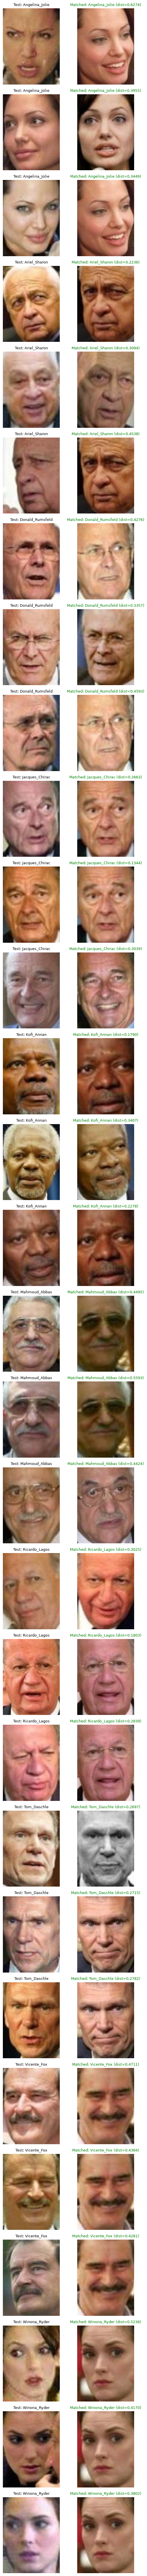

In [5]:
SHOW_ONLY = "all"  # "all", "wrong", or an integer like 20

if SHOW_ONLY == "all":
    to_show = results
elif SHOW_ONLY == "wrong":
    to_show = [r for r in results if r["verdict"] != "CORRECT"]
else:
    to_show = results[:int(SHOW_ONLY)]

if not to_show:
    print("Nothing to show for this SHOW_ONLY setting.")
else:
    n = len(to_show)
    fig, axes = plt.subplots(n, 2, figsize=(6, 3 * n))
    if n == 1:
        axes = axes.reshape(1, 2)

    for row, r in enumerate(to_show):
        test_img = cv2.cvtColor(cv2.imread(r["photo_path"]), cv2.COLOR_BGR2RGB)
        axes[row, 0].imshow(test_img)
        axes[row, 0].set_title(f"Test: {r['expected']}", fontsize=9)
        axes[row, 0].axis("off")

        color = "green" if r["verdict"] == "CORRECT" else "red"
        if r["matched_path"] is not None:
            matched_img = cv2.cvtColor(cv2.imread(r["matched_path"]), cv2.COLOR_BGR2RGB)
            axes[row, 1].imshow(matched_img)
            dist_str = f"{r['distance']:.4f}" if r["distance"] is not None else "n/a"
            axes[row, 1].set_title(
                f"Matched: {r['predicted']} (dist={dist_str})", fontsize=9, color=color
            )
        else:
            axes[row, 1].imshow(
                [[[240, 240, 240]]], extent=(0, 1, 0, 1)
            )
            axes[row, 1].text(0.5, 0.5, "NO MATCH", ha="center", va="center", fontsize=11, color=color)
        axes[row, 1].axis("off")

    plt.tight_layout()
    plt.show()